<a href="https://colab.research.google.com/github/Sriva29/machine-learning-assignments/blob/main/Srivatsan_Sentiment_Analysis_Financial_News_Headlines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis of Financial News Headlines
## This task tests your ability to apply NLP techniques you've learnt to classify a news headline containing financial information into either one of the sentiments (Positive, Negative or Neutral)

### Dataset:
https://raw.githubusercontent.com/subashgandyer/datasets/main/financial_news_headlines_sentiment.csv

## Max Marks without Bonus attempted: 80 points
## Max Marks with Bonus: 100 points
- ### Bonus: 20 points

### Steps
- 1. Download the dataset
- 2. Load the dataset
- 3. Explore the dataset (Exploratory Data Analysis)
- 4. Clean the data
- 5. Apply SMOTE for imbalanced data [Optional] --> Carries Bonus Marks
- 6. Build a BoW model
- 7. Build a Tf-Idf model
- 8. Split train and test data
- 9. Use one ML Classifying algorithm to classify the finanical news headline data
- 10. Use another ML classifying algorithm to classify them
- 11. Plot Confusion matrix

## 1. Download the dataset [1 point]

In [ ]:
import pandas as pd
import numpy as np
# need notebook and python script
url = "https://raw.githubusercontent.com/subashgandyer/datasets/main/financial_news_headlines_sentiment.csv"
dataset = pd.read_csv(url, encoding='latin-1', header=None, names=['Sentiment', 'Headlines'])
print("Dataset downloaded successfully.")
dataset.head()

Dataset downloaded successfully.


,Sentiment,Headlines
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...


## 2. Load the dataset [1 point]

In [ ]:
print("First few rows of the dataset:")
print(dataset.head())

First few rows of the dataset:
  Sentiment                                          Headlines
0   neutral  According to Gran , the company has no plans t...
1   neutral  Technopolis plans to develop in stages an area...
2  negative  The international electronic industry company ...
3  positive  With the new production plant the company woul...
4  positive  According to the company 's updated strategy f...


## 3. Explore the dataset [10 points]

In [ ]:
print("\nDataset Summary:")
print(dataset.describe())
print("\nDataset Info:")
print(dataset.info())
print("\nDistribution of Sentiments:")
print(dataset['Sentiment'].value_counts())


Dataset Summary:
       Sentiment                                          Headlines
count       4846                                               4846
unique         3                                               4838
top      neutral  TELECOMWORLDWIRE-7 April 2006-TJ Group Plc sel...
freq        2879                                                  2

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4846 entries, 0 to 4845
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sentiment  4846 non-null   object
 1   Headlines  4846 non-null   object
dtypes: object(2)
memory usage: 75.8+ KB
None

Distribution of Sentiments:
Sentiment
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64


## 4. Clean the data [5 points]

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Remove punctuation, lowercase, remove stopwords
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.lower()
    text = text.split()
    text = [word for word in text if word not in stop_words]
    return ' '.join(text)

dataset['Cleaned_Headlines'] = dataset['Headlines'].apply(clean_text)
print("\nFirst few cleaned headlines:")
print(dataset[['Headlines', 'Cleaned_Headlines']].head())


First few cleaned headlines:
                                           Headlines  \
0  According to Gran , the company has no plans t...   
1  Technopolis plans to develop in stages an area...   
2  The international electronic industry company ...   
3  With the new production plant the company woul...   
4  According to the company 's updated strategy f...   

                                   Cleaned_Headlines  
0  according gran company plans move production r...  
1  technopolis plans develop stages area less squ...  
2  international electronic industry company elco...  
3  new production plant company would increase ca...  
4  according company updated strategy years baswa...  


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 5. SMOTE (Imbalanced dataset) [OPTIONAL] BONUS [20 points]
Hint: Use **imblearn** library

In [ ]:
# Step 5: Apply SMOTE for imbalanced data [Optional]
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=37)

X = dataset['Cleaned_Headlines']
y = dataset['Sentiment']

# Convert text data to numerical using Tf-Idf for SMOTE compatibility
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(X).toarray()

# Apply SMOTE to balance the classes
X_smote, y_smote = smote.fit_resample(X_tfidf, y)
print("\nAfter SMOTE, distribution of Sentiments:")
print(pd.Series(y_smote).value_counts())


After SMOTE, distribution of Sentiments:
Sentiment
neutral     2879
negative    2879
positive    2879
Name: count, dtype: int64


## 6. BoW model [15 points]

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(max_features=5000)
X_bow = bow_vectorizer.fit_transform(dataset['Cleaned_Headlines']).toarray()
print("\nBag of Words model created.")


Bag of Words model created.


## 7. Tf-idf model [15 points]

In [ ]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(dataset['Cleaned_Headlines']).toarray()
print("\nTF-IDF model created.")


TF-IDF model created.


## 8. Split train test data [3 points]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_tfidf, dataset['Sentiment'], test_size=0.2, random_state=37)
print("\nData split into train and test sets.")


Data split into train and test sets.


## 9. Classification Algorithm [10 points]
- Train
- Predict

In [ ]:
#Using logistic regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

lr_classifier = LogisticRegression()
lr_classifier.fit(X_train, y_train)
y_pred_lr = lr_classifier.predict(X_test)

print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))


Logistic Regression Classification Report:
              precision    recall  f1-score   support

    negative       0.81      0.43      0.56       110
     neutral       0.72      0.95      0.82       571
    positive       0.78      0.43      0.55       289

    accuracy                           0.74       970
   macro avg       0.77      0.60      0.65       970
weighted avg       0.75      0.74      0.71       970



## 10. Another Classification Algorithm [10 points]
- Train
- Predict

In [ ]:
# Using Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=37)
rf_classifier.fit(X_train, y_train)
y_pred_rf = rf_classifier.predict(X_test)

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Classification Report:
              precision    recall  f1-score   support

    negative       0.71      0.41      0.52       110
     neutral       0.74      0.95      0.83       571
    positive       0.75      0.46      0.57       289

    accuracy                           0.74       970
   macro avg       0.73      0.61      0.64       970
weighted avg       0.74      0.74      0.72       970



## 11. Confusion Matrixes for two classification algorithms and two feature extractor methods [10 points]

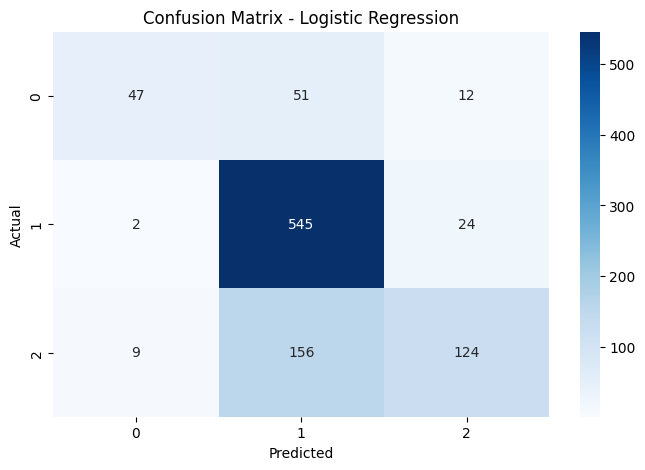

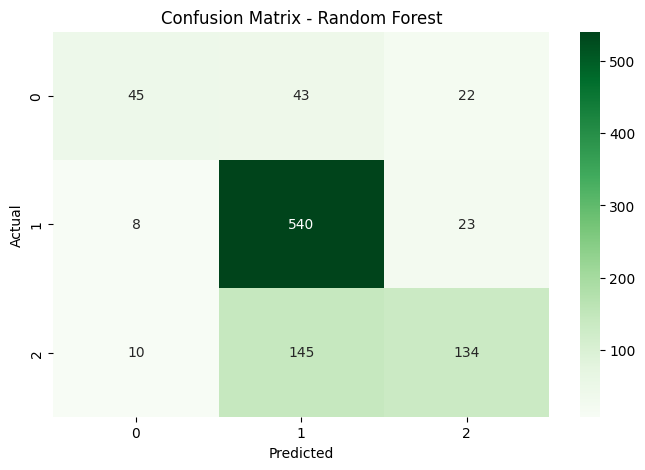

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# Conclusion

It looks like both models predict neutral better than positive or negative. Perhaps SMOTE needs to be tweaked and hyperparameter tuning done to improve the model accuracy.